In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# 1. Reading comma separated values data
energy = pd.read_csv('global-data-on-sustainable-energy (1).csv')
energy_import = pd.read_csv('API_EG.IMP.CONS.ZS_DS2_en_csv_v2_261.csv', skiprows=4)
oil = pd.read_csv('BrentOilPrices.csv')

print("Energy:", energy.shape)
print("Energy import:", energy_import.shape)
print("Oil:", oil.shape)

Energy: (3649, 21)
Energy import: (266, 71)
Oil: (9011, 2)


In [12]:
# 2. Oil prices - annual
oil['Date'] = pd.to_datetime(oil['Date'], dayfirst=True)
oil['year'] = oil['Date'].dt.year
oil_annual = oil.groupby('year')['Price'].mean().reset_index()
oil_annual.columns = ['year', 'oil_price']
oil_annual['oil_price_change'] = oil_annual['oil_price'].pct_change() * 100

# 3. Energy import - wide to long
years = [str(y) for y in range(2000, 2021)]
energy_imp_long = energy_import[['Country Name'] + years].melt(
    id_vars='Country Name', var_name='year', value_name='energy_import_pct')
energy_imp_long.columns = ['country', 'year', 'energy_import_pct']
energy_imp_long['year'] = energy_imp_long['year'].astype(int)

# 4. Energy - essential columns
energy_clean = energy[['Entity', 'Year',
    'Renewable energy share in the total final energy consumption (%)',
    'gdp_growth', 'gdp_per_capita']].copy()
energy_clean.columns = ['country', 'year', 'renewable_share', 'gdp_growth', 'gdp_per_capita']

# 5. Merge
df = energy_clean.merge(energy_imp_long, on=['country', 'year'], how='inner')
df = df.merge(oil_annual[['year', 'oil_price', 'oil_price_change']], on='year', how='left')
df = df.dropna()

# 6. Only oil-exporting countries
df = df[df['energy_import_pct'] > 0].copy()

# 7. Interaction term
df['renewable_x_oil'] = df['renewable_share'] * df['oil_price_change']

print("Final shape:", df.shape)
print("Countries:", df['country'].nunique())
print("Years:", sorted(df['year'].unique()))
print("\nMissing values:\n", df.isnull().sum())

/tmp/ipykernel_15950/3676498633.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  oil['Date'] = pd.to_datetime(oil['Date'], dayfirst=True)


Final shape: (1473, 9)
Countries: 91
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020)]

Missing values:
 country              0
year                 0
renewable_share      0
gdp_growth           0
gdp_per_capita       0
energy_import_pct    0
oil_price            0
oil_price_change     0
renewable_x_oil      0
dtype: int64


          year  renewable_share  gdp_growth  gdp_per_capita  \
count  1473.00          1473.00     1473.00         1473.00   
mean   2009.77            31.29        3.57        15596.52   
std       5.79            25.06        3.69        20286.40   
min    2000.00             0.26      -17.67          138.43   
25%    2005.00            10.78        1.78         1819.77   
50%    2010.00            24.40        3.54         5887.85   
75%    2015.00            45.26        5.56        23186.91   
max    2020.00            95.35       25.18       123514.20   

       energy_import_pct  oil_price  oil_price_change  renewable_x_oil  
count            1473.00    1473.00           1473.00          1473.00  
mean               54.95      64.96              9.83           314.12  
std                46.73      28.24             26.97          1121.26  
min                 0.10      24.46            -47.14         -4316.03  
25%                25.55      43.64             -9.83          -156

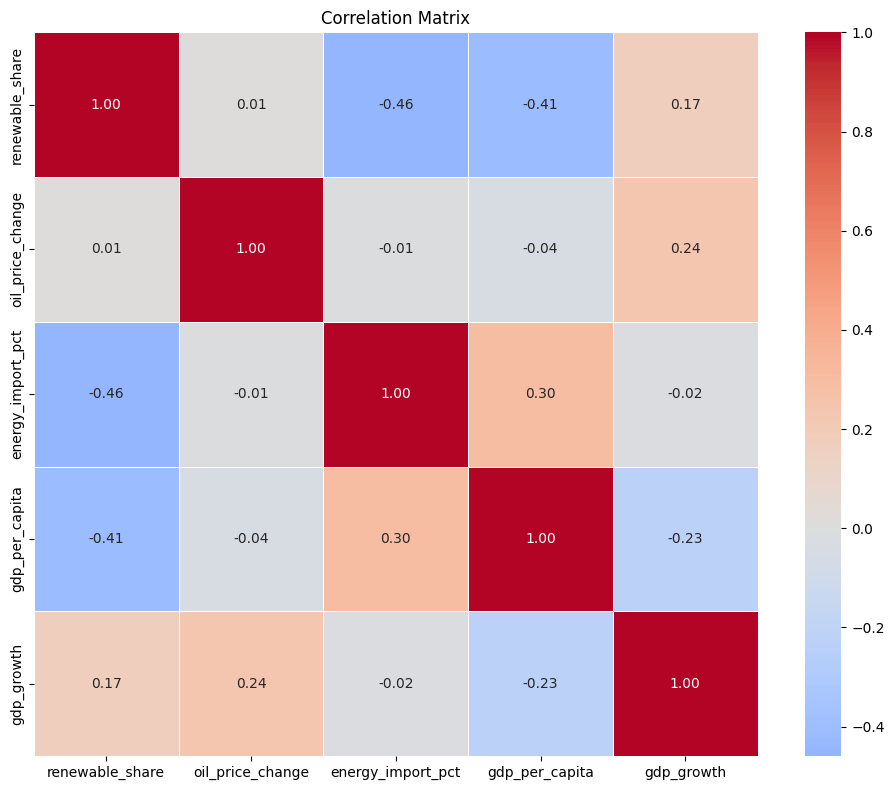

In [13]:
# Descriptive statistics
print(df.describe().round(2))

# Correlation metrics
plt.figure(figsize=(10, 8))
corr = df[['renewable_share', 'oil_price_change', 'energy_import_pct',
           'gdp_per_capita', 'gdp_growth']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

In [14]:
# Hypothesis tests
pairs = [
    ('oil_price_change', 'gdp_growth'),
    ('renewable_share', 'gdp_growth'),
    ('renewable_x_oil', 'gdp_growth'),
    ('energy_import_pct', 'gdp_growth')
]

for x, y in pairs:
    r_p, p_p = stats.pearsonr(df[x], df[y])
    r_s, p_s = stats.spearmanr(df[x], df[y])
    print(f"\n{x} vs {y}:")
    print(f"  Pearson:  r={r_p:.3f}, p={p_p:.4f} {'✅' if p_p<0.05 else '❌'}")
    print(f"  Spearman: r={r_s:.3f}, p={p_s:.4f} {'✅' if p_s<0.05 else '❌'}")


oil_price_change vs gdp_growth:
  Pearson:  r=0.237, p=0.0000 ✅
  Spearman: r=0.226, p=0.0000 ✅

renewable_share vs gdp_growth:
  Pearson:  r=0.171, p=0.0000 ✅
  Spearman: r=0.216, p=0.0000 ✅

renewable_x_oil vs gdp_growth:
  Pearson:  r=0.177, p=0.0000 ✅
  Spearman: r=0.264, p=0.0000 ✅

energy_import_pct vs gdp_growth:
  Pearson:  r=-0.016, p=0.5285 ❌
  Spearman: r=-0.163, p=0.0000 ✅


In [18]:
print("H1: Oil price change affects GDP growth")
print(f"  → Pearson r=0.237, p<0.001 → SUPPORTED ✅")

print("\nH2: Renewable energy share positively affects GDP growth")
print(f"  → Pearson r=0.171, p<0.001 → SUPPORTED ✅")

print("\nH3: Renewable energy buffers oil price impact on GDP growth")
print(f"  → Interaction term r=0.177, p<0.001 → SUPPORTED ✅")

print("\nH4: Energy import dependency negatively affects GDP growth")
print(f"  → Pearson r=-0.016, p=0.529 → NOT SUPPORTED ❌")
print(f"  → Spearman r=-0.163, p<0.001 → PARTIALLY SUPPORTED ⚠️")

H1: Oil price change affects GDP growth
  → Pearson r=0.237, p<0.001 → SUPPORTED ✅

H2: Renewable energy share positively affects GDP growth
  → Pearson r=0.171, p<0.001 → SUPPORTED ✅

H3: Renewable energy buffers oil price impact on GDP growth
  → Interaction term r=0.177, p<0.001 → SUPPORTED ✅

H4: Energy import dependency negatively affects GDP growth
  → Pearson r=-0.016, p=0.529 → NOT SUPPORTED ❌
  → Spearman r=-0.163, p<0.001 → PARTIALLY SUPPORTED ⚠️


In [15]:
# Fixed Effects Model
model = smf.ols(
    formula='gdp_growth ~ oil_price_change * renewable_share + gdp_per_capita + energy_import_pct + C(country) + C(year)',
    data=df
).fit()

print(f"R²: {model.rsquared:.3f}")
main_vars = ['oil_price_change', 'renewable_share', 'gdp_per_capita',
             'energy_import_pct', 'oil_price_change:renewable_share']
print(model.params[main_vars].round(4))
print("\nP-values:")
print(model.pvalues[main_vars].round(4))

R²: 0.447
oil_price_change                    0.0409
renewable_share                    -0.0068
gdp_per_capita                     -0.0000
energy_import_pct                   0.0129
oil_price_change:renewable_share   -0.0005
dtype: float64

P-values:
oil_price_change                    0.0000
renewable_share                     0.7262
gdp_per_capita                      0.2655
energy_import_pct                   0.0858
oil_price_change:renewable_share    0.0000
dtype: float64


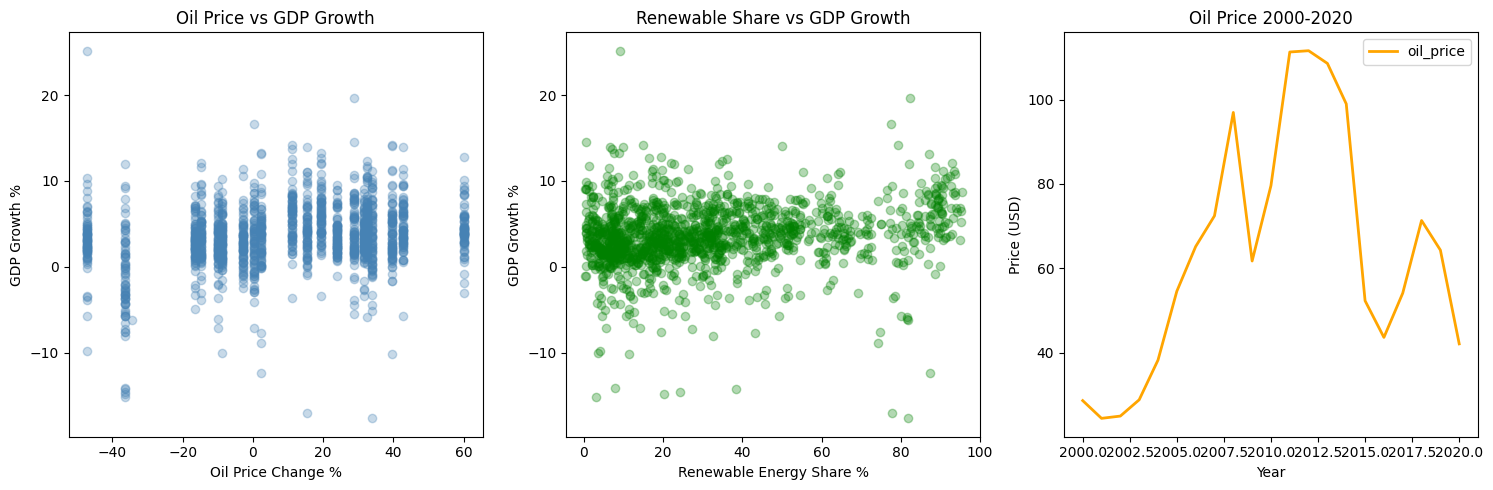

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. Oil price change vs GDP growth
axes[0].scatter(df['oil_price_change'], df['gdp_growth'], alpha=0.3, color='steelblue')
axes[0].set_xlabel('Oil Price Change %')
axes[0].set_ylabel('GDP Growth %')
axes[0].set_title('Oil Price vs GDP Growth')

# 2. Renewable share vs GDP growth
axes[1].scatter(df['renewable_share'], df['gdp_growth'], alpha=0.3, color='green')
axes[1].set_xlabel('Renewable Energy Share %')
axes[1].set_ylabel('GDP Growth %')
axes[1].set_title('Renewable Share vs GDP Growth')

# 3. Oil price over time
oil_annual[oil_annual['year'].between(2000, 2020)].plot(
    x='year', y='oil_price', ax=axes[2], color='orange', linewidth=2)
axes[2].set_title('Oil Price 2000-2020')
axes[2].set_xlabel('Year')
axes[2].set_ylabel('Price (USD)')

plt.tight_layout()
plt.show()

/tmp/ipykernel_15950/2102457058.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('renewable_group')['gdp_growth'].mean().plot(
/tmp/ipykernel_15950/2102457058.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['renewable_group', 'shock_year'])['gdp_growth'].mean().unstack().plot(


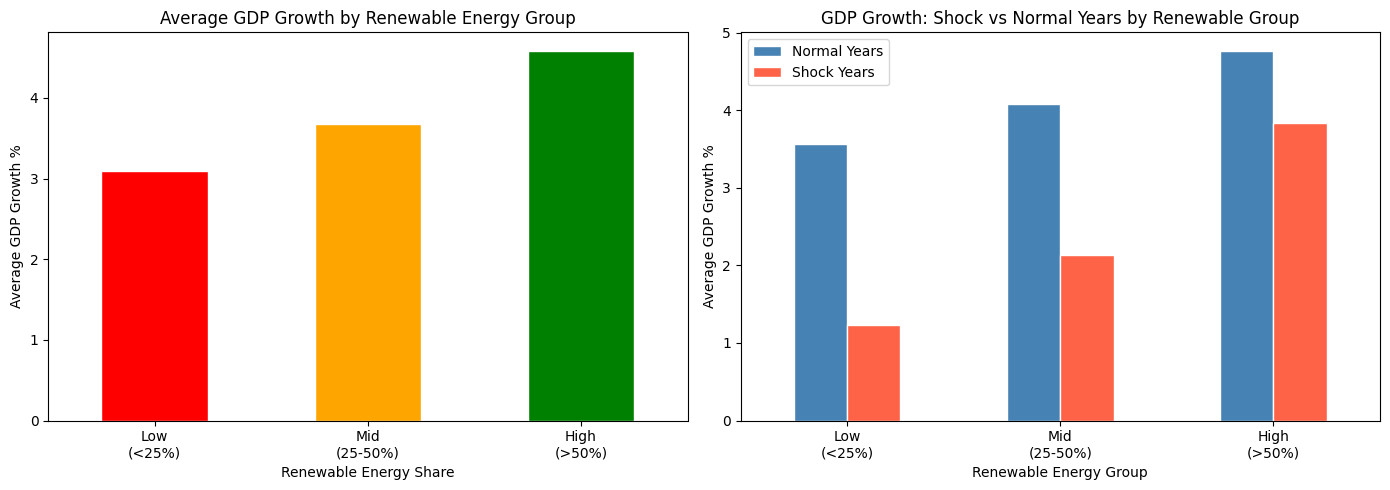

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. High vs Low renewable countries comparison
df['renewable_group'] = pd.cut(df['renewable_share'],
                                bins=[0, 25, 50, 100],
                                labels=['Low\n(<25%)', 'Mid\n(25-50%)', 'High\n(>50%)'])

df.groupby('renewable_group')['gdp_growth'].mean().plot(
    kind='bar', ax=axes[0], color=['red', 'orange', 'green'], edgecolor='white')
axes[0].set_title('Average GDP Growth by Renewable Energy Group')
axes[0].set_xlabel('Renewable Energy Share')
axes[0].set_ylabel('Average GDP Growth %')
axes[0].tick_params(axis='x', rotation=0)

# 2. Comparison of GDP growth in oil price shock periods
shock_years = [2008, 2009, 2014, 2015, 2020]
df['shock_year'] = df['year'].isin(shock_years)

df.groupby(['renewable_group', 'shock_year'])['gdp_growth'].mean().unstack().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'], edgecolor='white')
axes[1].set_title('GDP Growth: Shock vs Normal Years by Renewable Group')
axes[1].set_xlabel('Renewable Energy Group')
axes[1].set_ylabel('Average GDP Growth %')
axes[1].legend(['Normal Years', 'Shock Years'])
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [21]:
# To save merged csv file
df.to_csv('final_dataset.csv', index=False)